# Student Perception Results Analysis

This notebook presents a brief analysis of the results discussed in this research paper. The notebook is structured as follows:

1. **Initial setup:** Necessary initial configurations, such as customizing dataframes to display the full content of rows and columns, styling the presented tables, and providing functions to convert PDF figures to PNG format to enable their display in this Jupyter Notebook.
2. **Pipeline methodology:** Presentation of two supplementary visualizations — Topic Vector Representation and LLM Topic Labeling Methodology — to illustrate the key stages of the analytical pipeline employed in this study.
3. **Defining the $k$ topics number:** Presentation of the $C_v$ coherence and topic diversity (IRBO) charts to determine the optimal number of topics for each model.
4. **Topic modeling:** Presentation of all topics generated by each of the modeling algorithms.
5. **Qualitative comparative inter-model analysis:**
   * **UMAP visualization:** Projection of all topics into a shared two-dimensional space.
   * **Common topics:** Presentation of the common topics across models, found using a similarity graph and community detection with the Louvain algorithm.
   * **Exclusive topics:** Presentation of the exclusive topics detected by a single model, also found using a similarity graph and community detection with the Louvain algorithm.
   * **Topic frequency distribution:** Identification of the three most recurrent topics for each model based on relative frequency analysis.
6. **Automatic generative topic labeling:** Presentation of the automatic labels generated by the Llama LLM for the topics produced by the BERTopic algorithm.

> **Note:** This notebook also includes supplementary visualizations produced during the research that could not be incorporated into the paper body due to the maximum page limit imposed by the conference submission guidelines. These additional visualizations include:
> * Operations performed to generate the vector representation for topics in the inter-model analysis,
> * Steps of the automatic labeling process using the LLM,
> * UMAP dimensionality projection of topics across models, and
> * Top-3 most frequent topics per model.

> **Disclaimer regarding language:** It is important to highlight that the original dataset and all raw results — including both the topic modeling outputs and the automatic generative labeling — were originally processed and obtained in Portuguese. However, to align with the language requirements of this research paper and facilitate the comprehension, the results presented in this notebook have been translated into English.

## Initial setup

### Dependencies and Environment Configuration
In this section, we import the necessary libraries and configure the display settings for Pandas DataFrames. This ensures that the qualitative and quantitative analysis tables are rendered correctly and comprehensively, preventing text truncation during the notebook presentation.

In [2]:
from pdf2image import convert_from_path
import os
from IPython.display import Image, display
import pandas as pd

In [3]:
# Show all rows
pd.set_option('display.max_rows', None)

# Show all cols
pd.set_option('display.max_columns', None)

# Show full content of each cell
pd.set_option('display.max_colwidth', None)

# Tables style
table_style = {
    'text-align': 'left',
    'border': '1px solid grey',
    'font-family': 'Arial',
}

### PDF to PNG Conversion Utility
Since the analytical plots generated during this research were originally exported in PDF format for high-resolution publication purposes, we define a helper function to convert these files into PNG format. This approach allows us to display the charts inline within the Jupyter environment without losing quality.

In [4]:
def convert_pdf_to_png(pdf_path, output_folder):
    # Convert the PDF into a list of images
    img = convert_from_path(pdf_path)
    
    # Get the file name without the '.pdf' extension
    base_name = os.path.splitext(os.path.basename(pdf_path))[0]
    
    for i, image in enumerate(img):
        # Define the output file name
        png_path = os.path.join(output_folder, f"{base_name}.png")
        # Save the image as a PNG file
        image.save(png_path, "PNG")
        print(f"Saved: {png_path}")

In [5]:
figures_path = "../output/figure/"

In [6]:
coherence_pdf = os.path.join(figures_path, "coherence_plot.pdf")
convert_pdf_to_png(coherence_pdf, figures_path)

Saved: ../output/figure/coherence_plot.png


In [7]:
irbo_pdf = os.path.join(figures_path, "irbo_plot.pdf")
convert_pdf_to_png(irbo_pdf, figures_path)

Saved: ../output/figure/irbo_plot.png


In [18]:
supertopics_pdf = os.path.join(figures_path, "super_topics.pdf")
convert_pdf_to_png(supertopics_pdf, figures_path)

Saved: ../output/figure/super_topics.png


## Pipeline Methodology

This section presents two supplementary visualizations — **Topic Vector Representation** and **LLM Topic Labeling Methodology** — designed to provide a clearer understanding of the analytical pipeline employed in this study. The first illustrates how topics from different models are transformed into a unified vectorial space to enable cross-model comparison, while the second depicts the automated labeling procedure used to generate human-interpretable semantic labels for each discovered topic.

### Topic Vector Representation

In this stage of the pipeline, each topic produced by the four models is converted into a *embedding* vectorial representation. To achieve this, the top 15 keywords of each topic are extracted, and their embeddings are generated using the Sentence-Transformer model `PORTULAN/serafim-335m-portuguese-pt-sentence-encoder-ir`. To represent each topic as a single semantic unit, the centroid (vector mean) of its keyword embeddings is computed. This approach enables the quantification of thematic correspondence between topics — even across different models — through the geometric proximity of their respective vectors. The figure below illustrates the operations involved in this stage.

Saved: ../output/figure/topics_vector_representation.png


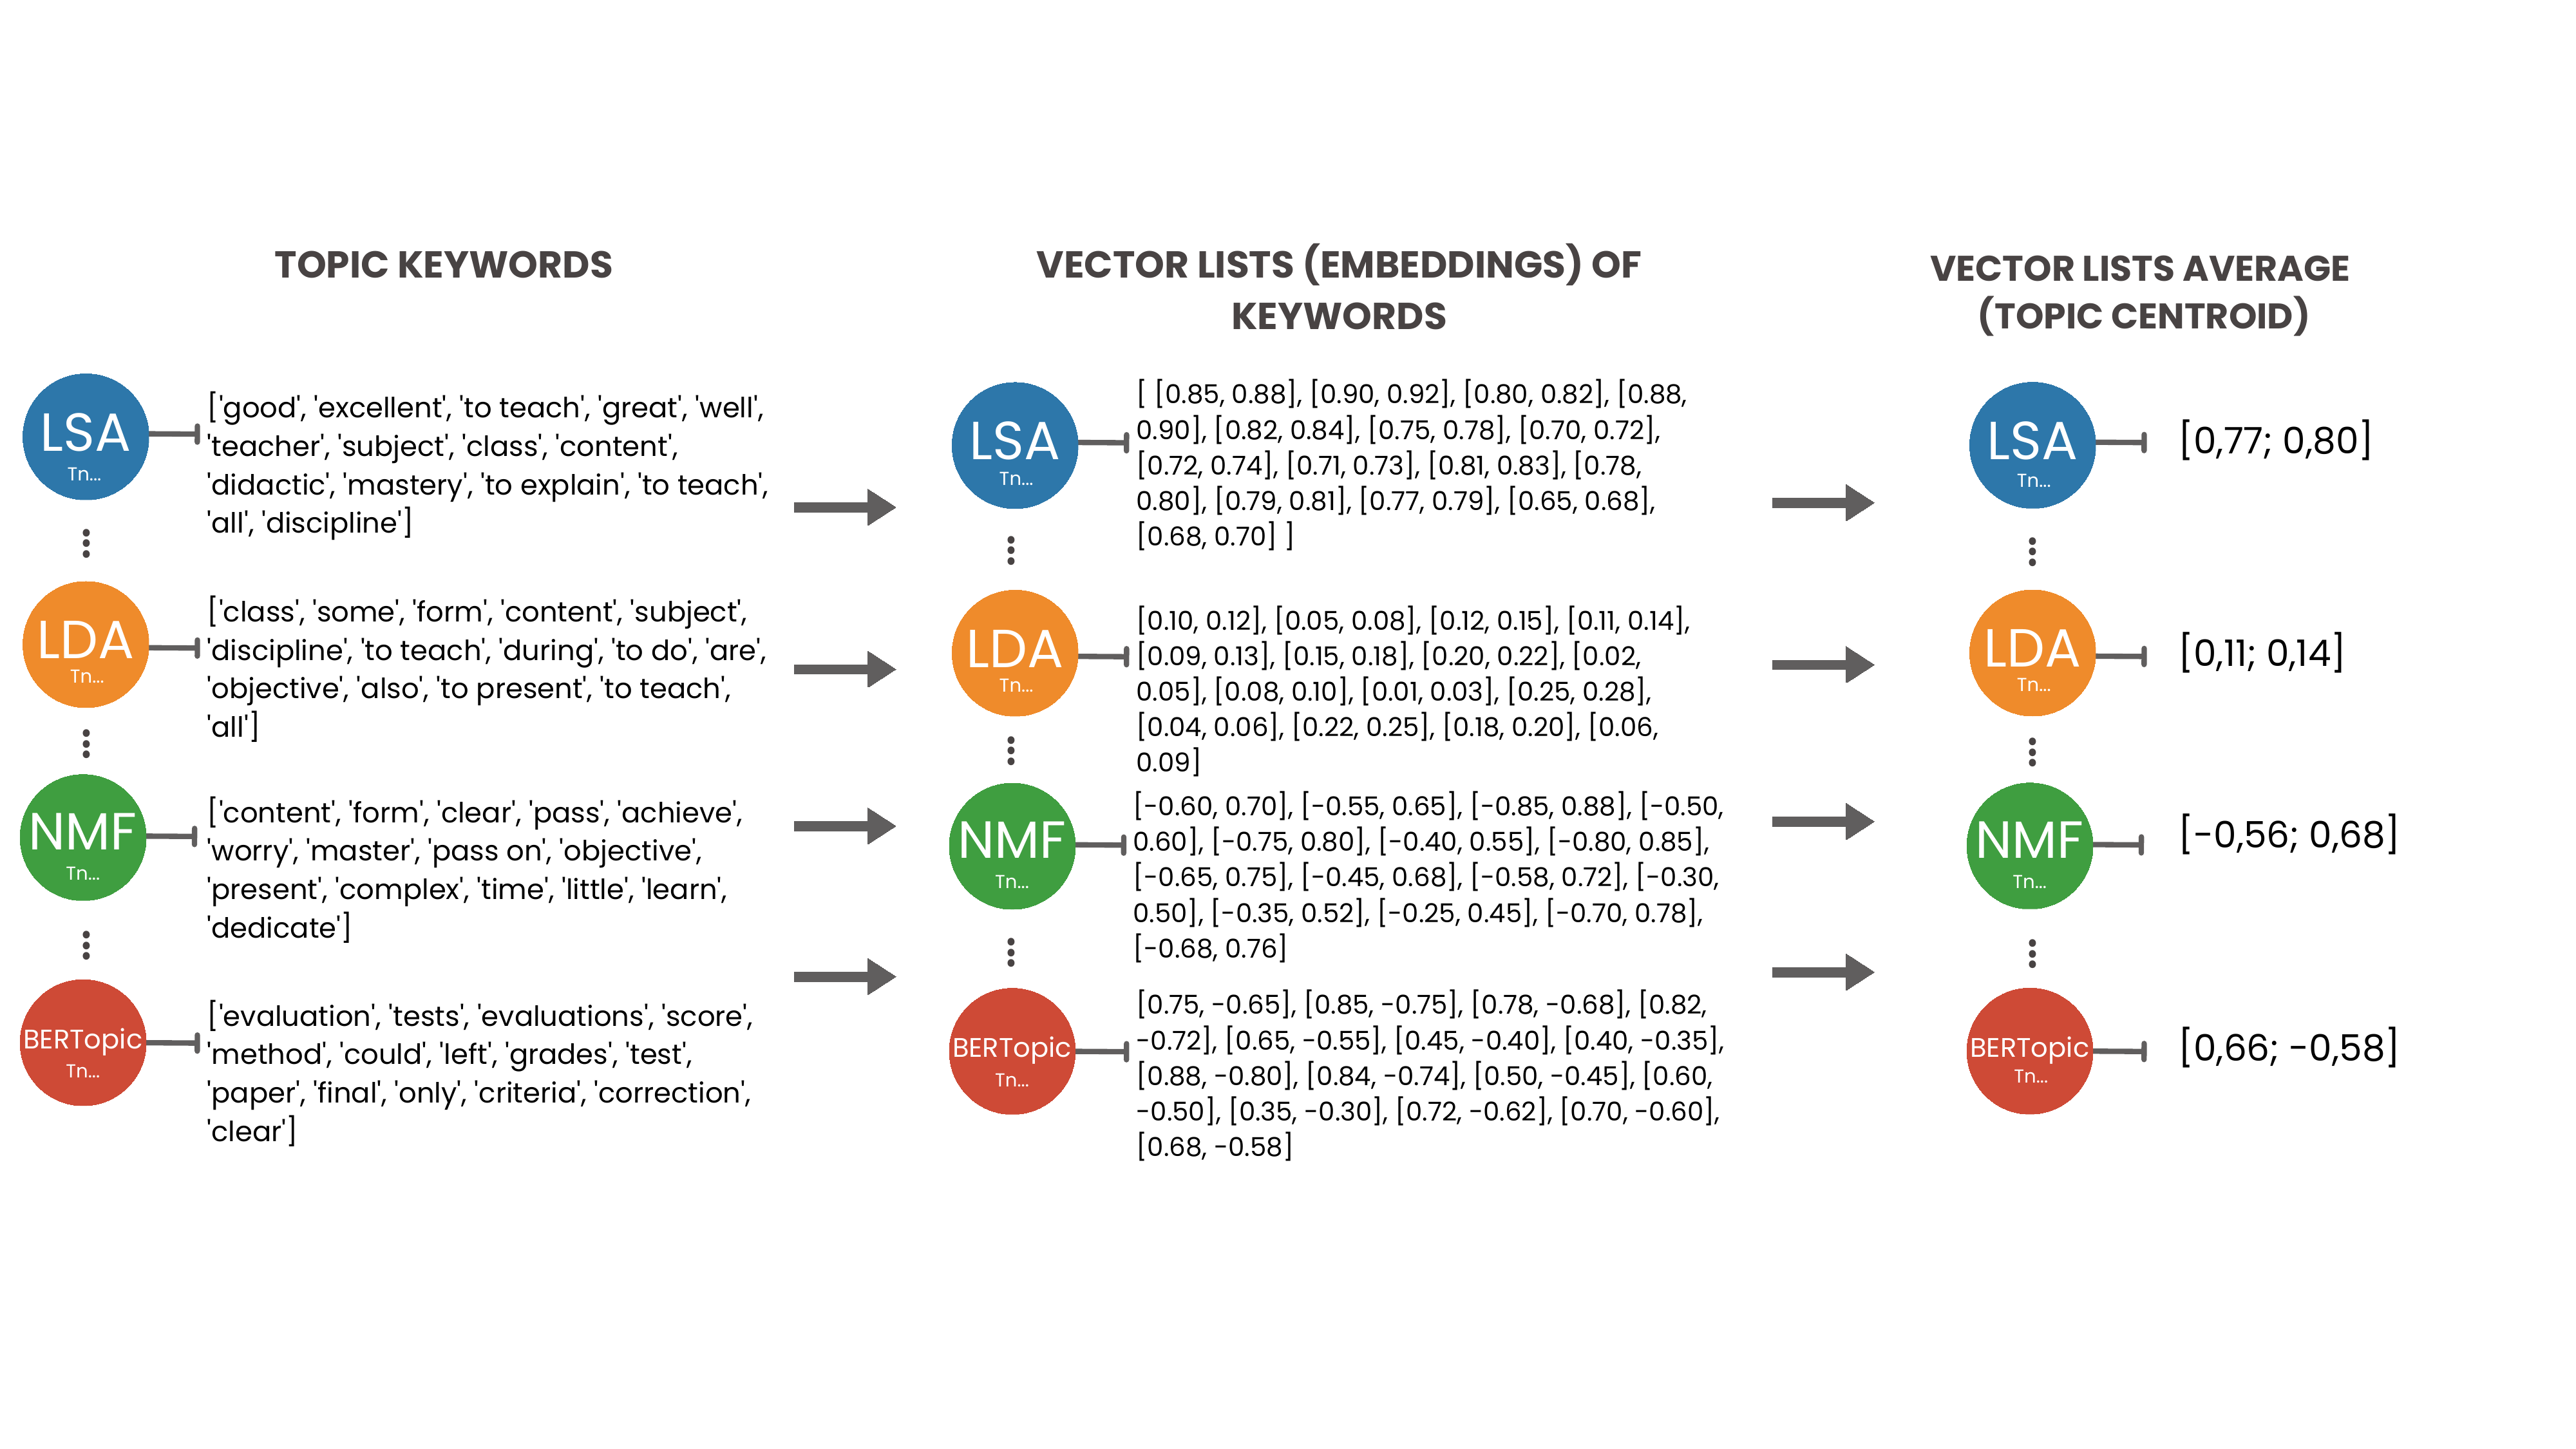

In [13]:
vector_representation = os.path.join(figures_path, "topics_vector_representation.pdf")
convert_pdf_to_png(vector_representation, figures_path)
display(Image(filename='../output/figure/topics_vector_representation.png', width='700px'))

### LLM Topic Labeling Methodology

The figure below illustrates the methodological workflow designed for the automated topic labeling procedure. The process begins with the **data input stage** (1), in which the input structure incorporates both the topic keywords and the representative documents associated with each topic. Next, **Prompt Engineering** techniques are applied (2), comprising three key components: (i) *Persona* prompting, instructing the LLM to act as a specialist in educational feedback analysis; (ii) the imposition of strict *System Instructions* focused on anonymization and output standardization; and (iii) the adoption of a *Zero-Shot* prompting approach. Finally, the model processes the enriched context to generate a concise and descriptive label for each topic.

Saved: ../output/figure/llm_labeling_metodology.png


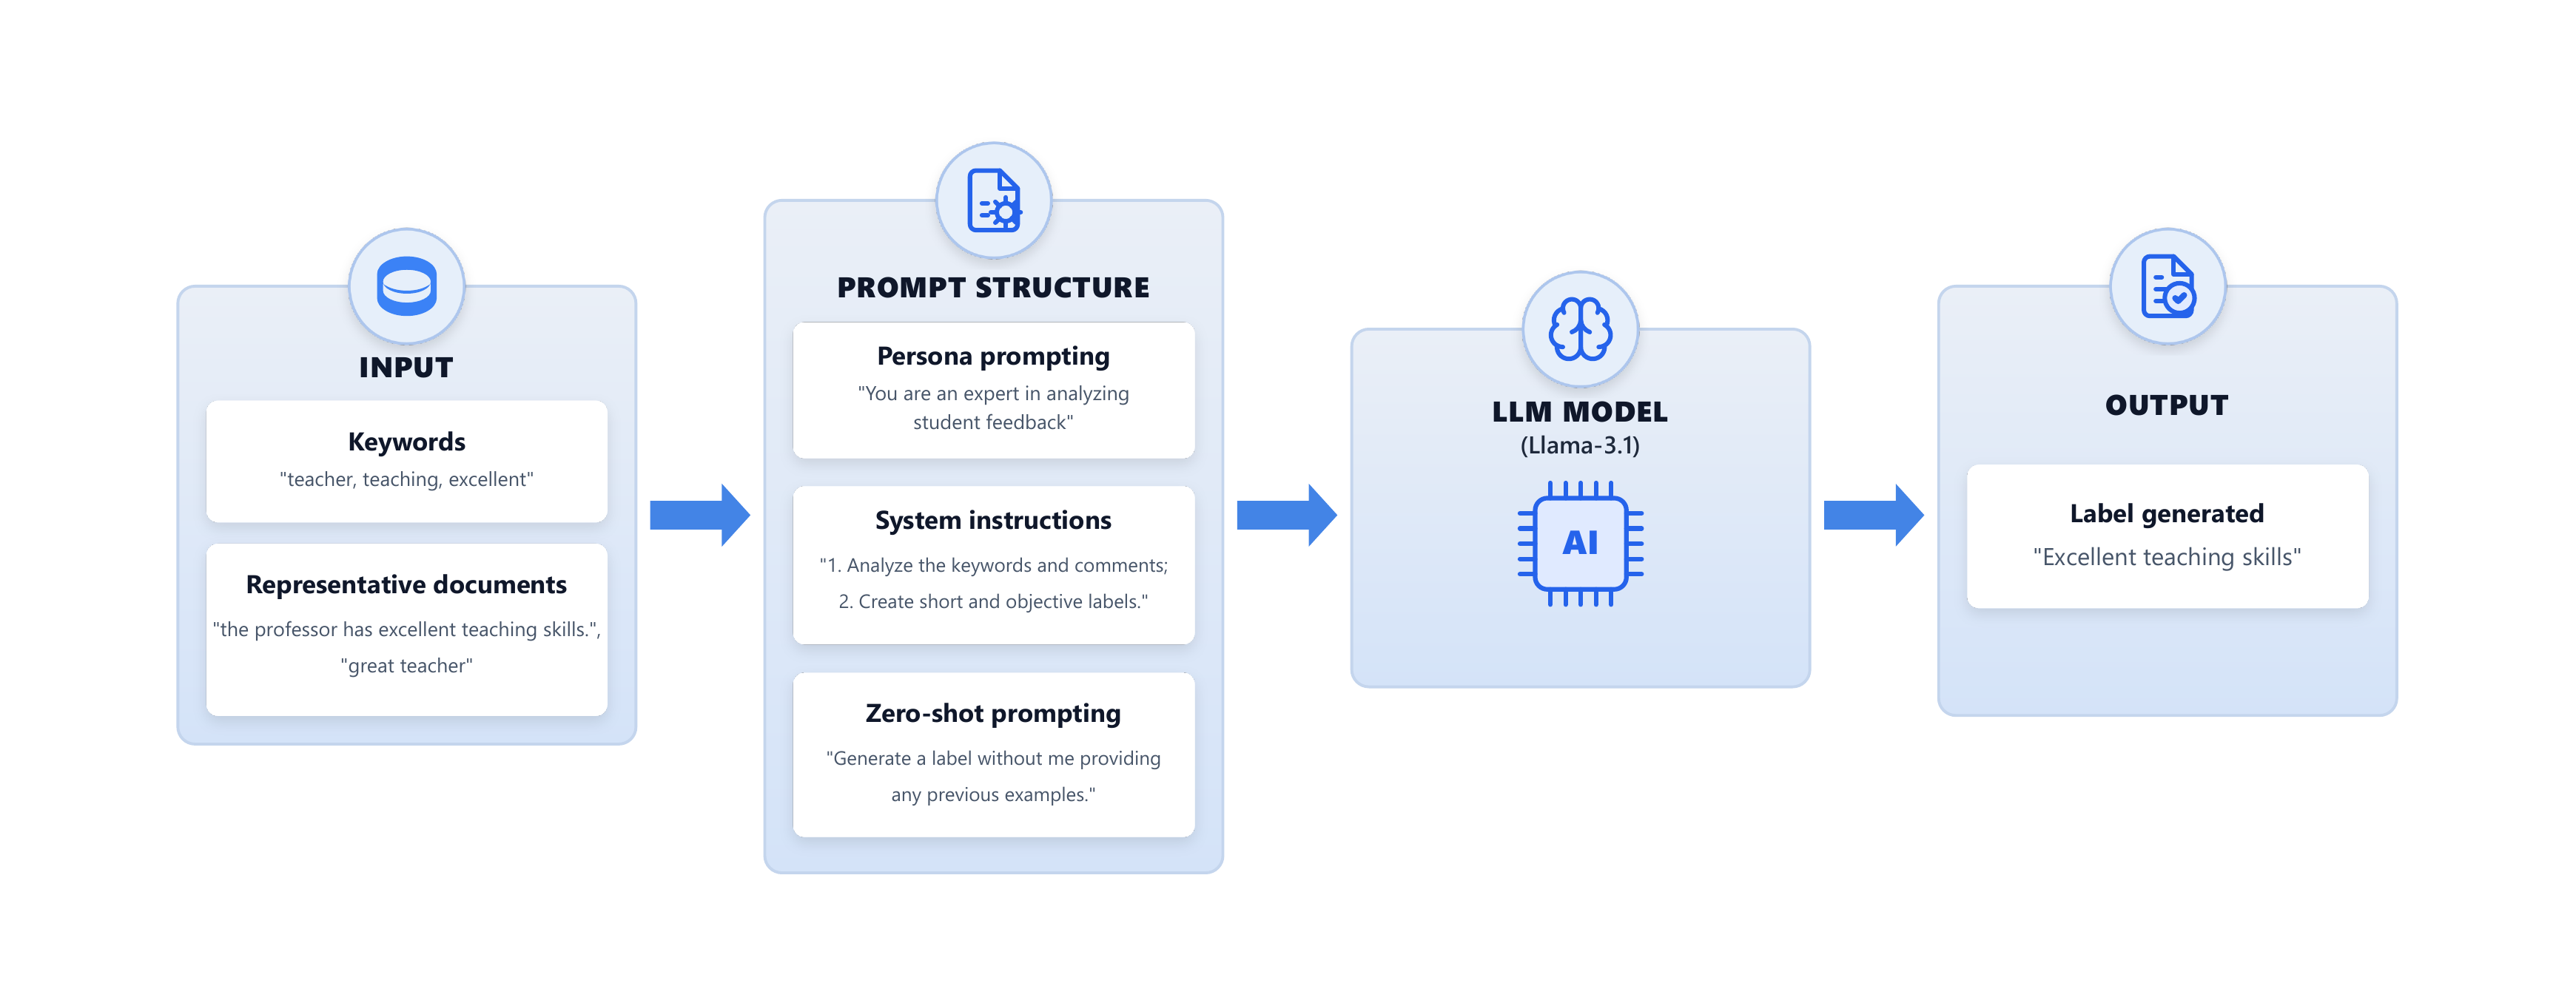

In [12]:
llm_labeling_metodology = os.path.join(figures_path, "llm_labeling_metodology.pdf")
convert_pdf_to_png(llm_labeling_metodology, figures_path)
display(Image(filename='../output/figure/llm_labeling_metodology.png', width='700px'))

## Topic Granularity ($k$) Definition
In topic modeling, determining the ideal number of topics ($k$) is a critical step to achieve a balance between model interpretability and topic diversity. In this section, we evaluate the performance of our four models across different values of $k$ using two metrics: Topic Coherence ($C_v$) and Topic Diversity (Inverted Rank-Biased Overlap (IRBO)).


### Coherence ($C_v$)
The $C_v$ coherence score measures the semantic similarity between the top words within each topic. A higher coherence indicates that the generated topics are more meaningful and human-interpretable. The chart below illustrates the coherence scores across different values of $k$ for the evaluated models.


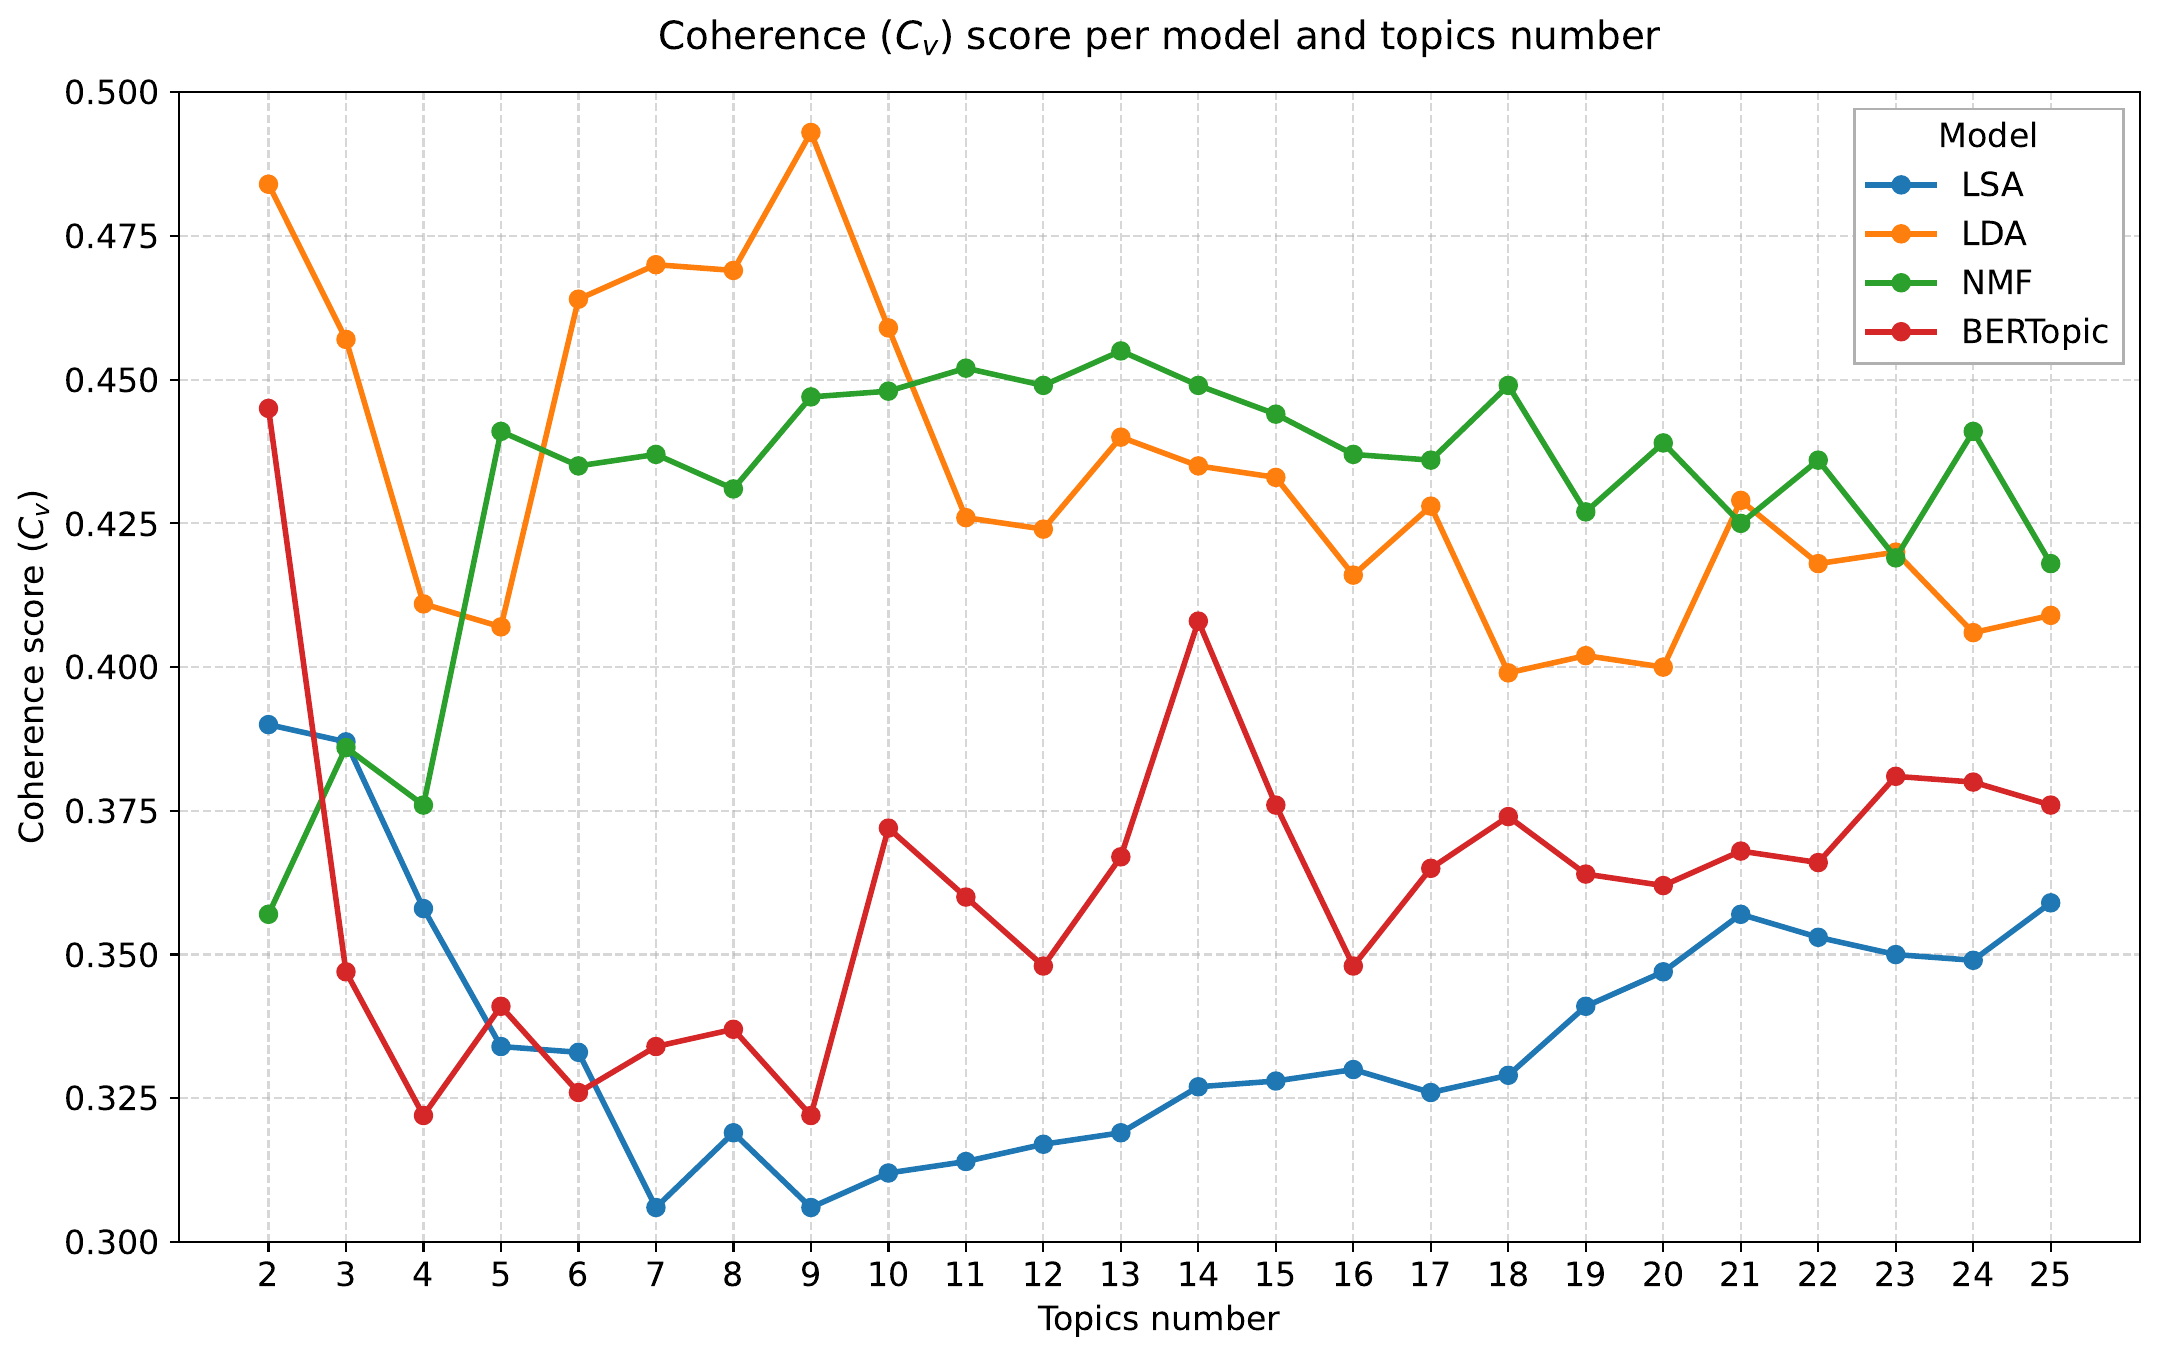

In [ ]:
display(Image(filename='../output/figure/coherence_plot.png', width='700px'))

### Topic Diversity (IRBO)
While coherence is essential, ensuring that the generated topics are distinct from one another is equally crucial to prevent thematic redundancy. The Inverted Rank-Biased Overlap (IRBO) metric quantifies topic diversity by measuring the overlap between the top words of different topics. Higher diversity values suggest that the model successfully captures distinct themes. The following plot details the IRBO scores for each model.


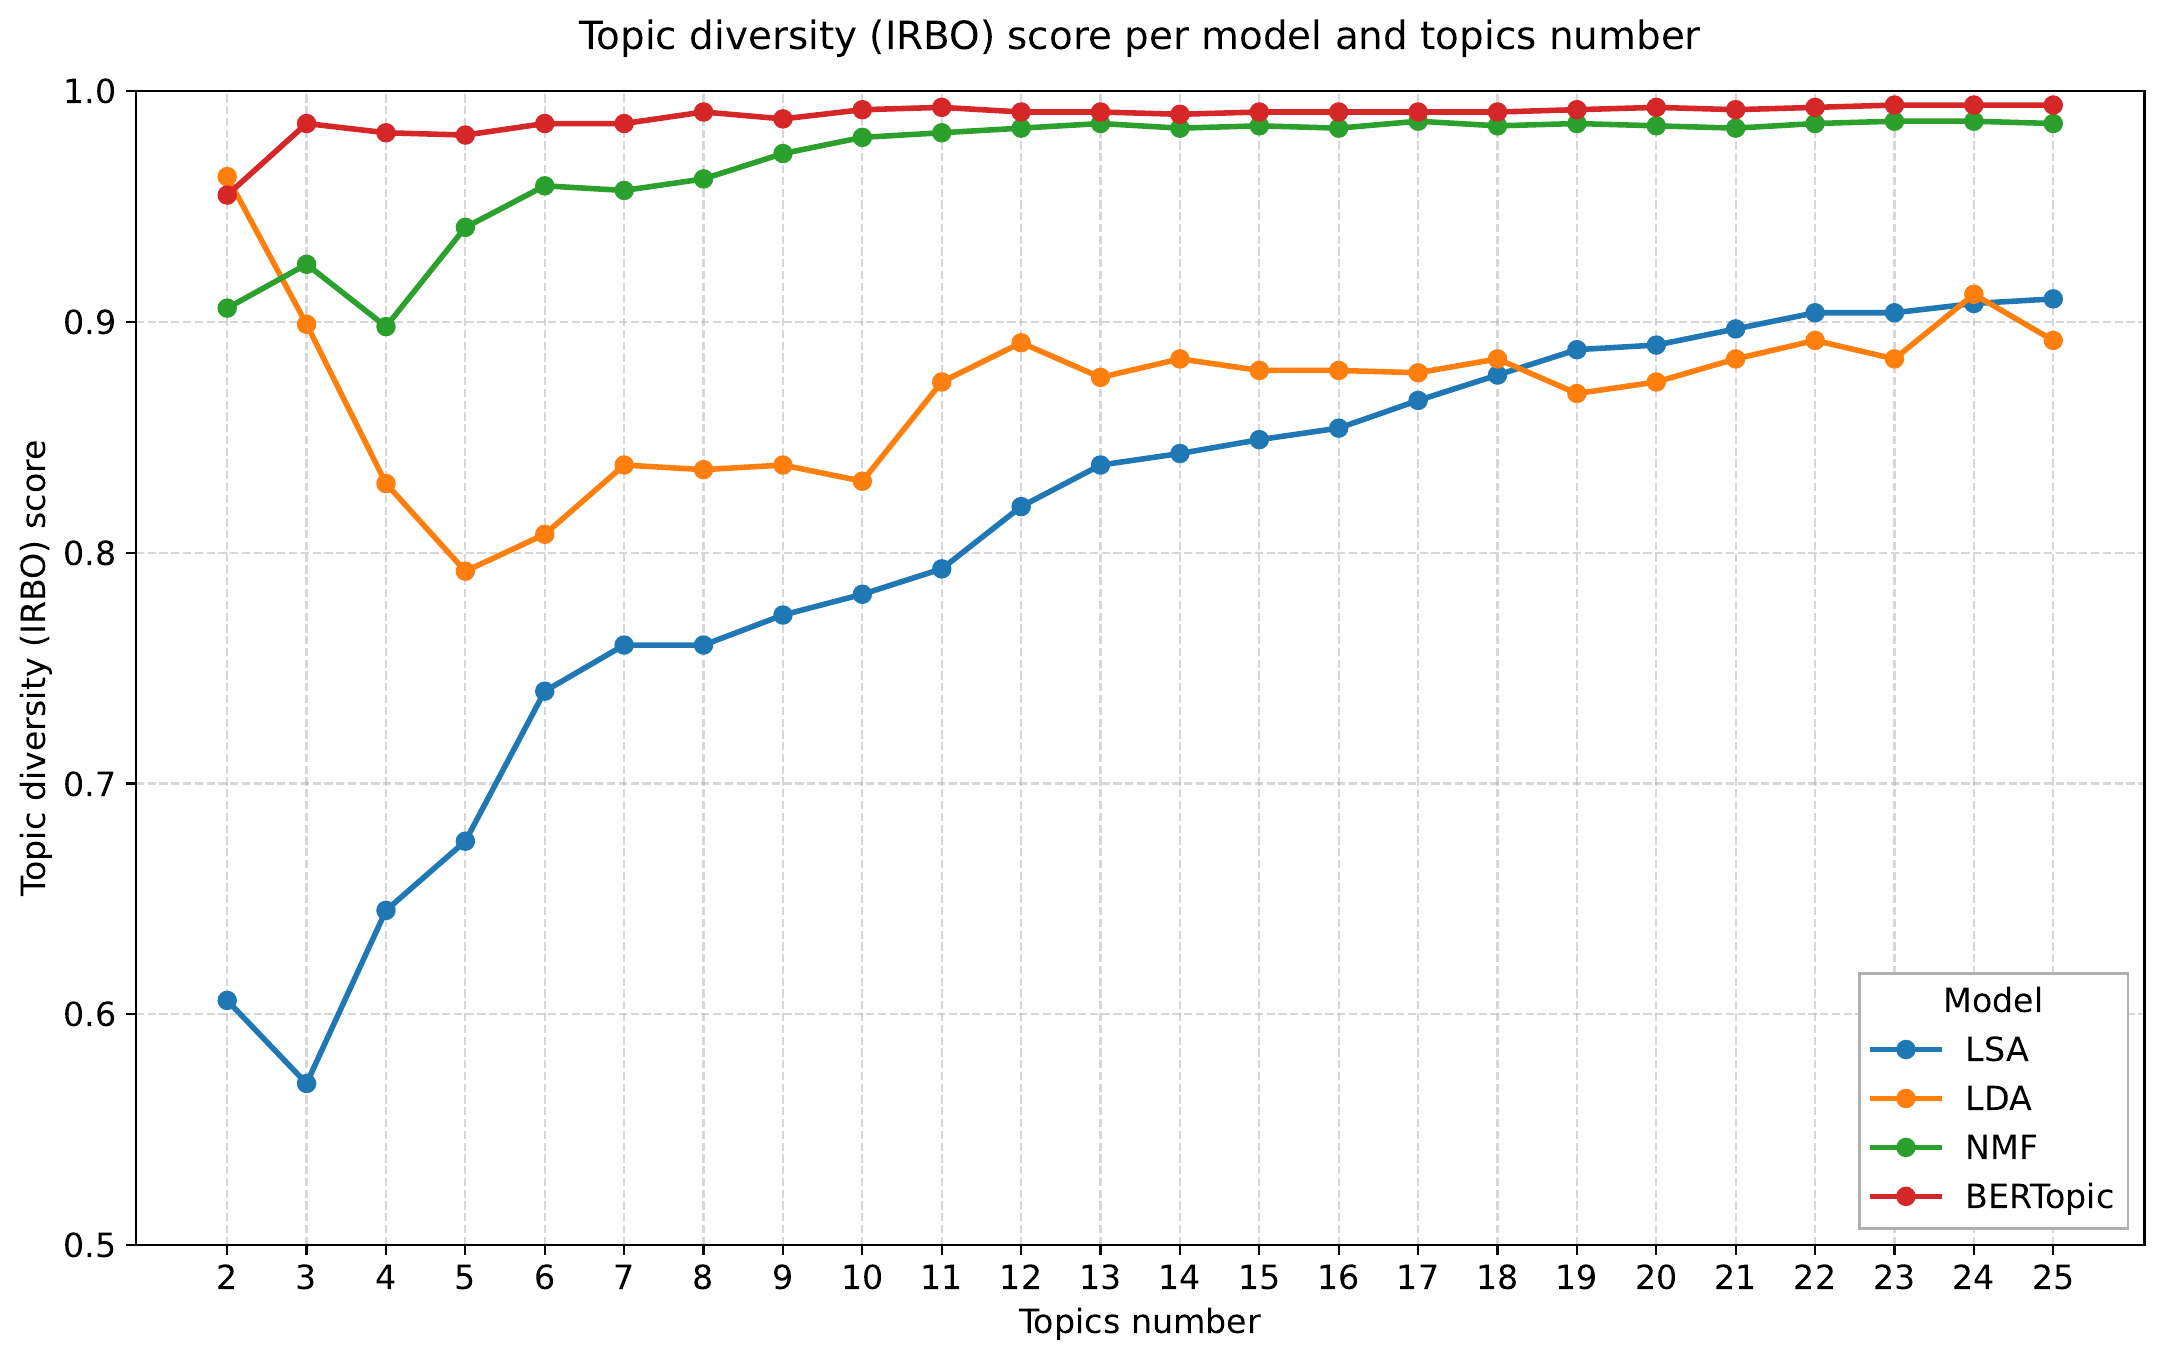

In [14]:
display(Image(filename='../output/figure/irbo_plot.png', width='700px'))

As discussed in the paper, based on the models' stability in the IRBO metric from $k=13$ onwards, and within our defined analytical window of interest ($13 \leq k \leq 25$), the chosen number of topics ($k$) for each model was:

* **LSA:** $k=25$
* **LDA and NMF:** $k=13$
* **BERTopic:** $k=14$

## Topic Modeling

Having established the number of topics ($k$) for each algorithm, this section presents the actual topic representations discovered by the LSA, LDA, NMF, and BERTopic models. For each algorithm, we display a structured table containing the resulting topics alongside their most representative keywords. These sets of keywords encapsulate the core semantic themes identified within the student perceptions dataset, serving as the basis for our subsequent qualitative analysis.

In [26]:
all_models_topics_en = pd.read_csv('../output/topic_modeling/all_models_topics_en.csv')

### LSA

In [27]:
lsa_table = all_models_topics_en[all_models_topics_en['model'] == 'lsa'][['keywords']]
lsa_table

,keywords
0,"['good', 'excellent', 'teaching', 'great', 'teacher', 'well', 'subject', 'class', 'didactic', 'content', 'domain', 'explain', 'teach', 'discipline', 'always']"
1,"['excellent', 'well', 'teaching', 'explain', 'subject', 'teach', 'content', 'great', 'discipline', 'good', 'pass', 'exam', 'know', 'class', 'miss']"
2,"['good', 'excellent', 'great', 'domain', 'teaching', 'subject', 'well', 'minister', 'content', 'way', 'pass', 'about', 'attentive', 'clear', 'discipline']"
3,"['great', 'good', 'well', 'teacher', 'class', 'explain', 'semester', 'dynamic', 'content', 'excellent', 'can', 'professional', 'attentive', 'do', 'interact']"
4,"['well', 'explain', 'subject', 'great', 'good', 'teacher', 'teach', 'domain', 'didactic', 'class', 'little', 'miss', 'improve', 'semester', 'exam']"
5,"['attentive', 'didactic', 'teacher', 'always', 'teaching', 'great', 'improve', 'helpful', 'help', 'need', 'explain', 'good', 'dedicate', 'doubt', 'domain']"
6,"['didactic', 'attentive', 'teaching', 'improve', 'domain', 'well', 'helpful', 'great', 'explain', 'always', 'need', 'teacher', 'help', 'subject', 'knowledge']"
7,"['domain', 'well', 'didactic', 'explain', 'subject', 'excellent', 'improve', 'attentive', 'teaching', 'content', 'class', 'enough', 'exam', 'minister', 'clear']"
8,"['teaching', 'teacher', 'domain', 'class', 'always', 'good', 'clear', 'didactic', 'improve', 'objective', 'minister', 'teach', 'need', 'help', 'about']"
9,"['teacher', 'attentive', 'teach', 'domain', 'improve', 'great', 'dedicate', 'professional', 'teaching', 'class', 'always', 'help', 'dynamic', 'wonderful', 'miss']"


### LDA

In [28]:
lda_table = all_models_topics_en[all_models_topics_en['model'] == 'lda'][['keywords']].reset_index(drop=True)
lda_table

,keywords
0,"['discipline', 'teacher', 'little', 'beyond', 'explain', 'well', 'time', 'subject', 'class', 'comment', 'study', 'during', 'class', 'schedule', 'minister']"
1,"['class', 'leave', 'semester', 'trabalho', 'minister', 'discipline', 'some', 'subject', 'room', 'content', 'can', 'give', 'class', 'do', 'knowledge']"
2,"['do', 'class', 'that', 'dynamic', 'know', 'attentive', 'great', 'always', 'subject_matter', 'schedule', 'need', 'help', 'content', 'teaching', 'give']"
3,"['class', 'semester', 'discipline', 'teacher', 'good', 'content', 'give', 'evaluative', 'have', 'learn', 'beyond', 'hour', 'all', 'professional', 'harm']"
4,"['class', 'evaluation', 'class', 'miss', 'all', 'subject_matter', 'discipline', 'point', 'some', 'teaching', 'semester', 'course', 'need', 'only', 'exam']"
5,"['exam', 'little', 'class', 'manage', 'miss', 'know', 'charge', 'student', 'room', 'be', 'have', 'for', 'content', 'people', 'pass']"
6,"['exam', 'class', 'pass', 'explain', 'content', 'trabalho', 'well', 'semester', 'beyond', 'do', 'discipline', 'evaluation', 'criterion', 'just', 'other']"
7,"['subject', 'do', 'always', 'well', 'explain', 'class', 'subject_matter', 'great', 'interest', 'are', 'speak', 'take', 'time', 'teach', 'teaching']"
8,"['subject', 'way', 'class', 'teach', 'subject_matter', 'because', 'can', 'do', 'student', 'way', 'some', 'clear', 'discipline', 'only', 'evaluation']"
9,"['discipline', 'class', 'well', 'all', 'only', 'do', 'good', 'course', 'can', 'content', 'activity', 'know', 'use', 'are', 'pass']"


### NMF

In [29]:
nmf_table = all_models_topics_en[all_models_topics_en['model'] == 'nmf'][['keywords']].reset_index(drop=True)
nmf_table

,keywords
0,"['class', 'pass', 'exam', 'content', 'do', 'discipline', 'trabalho', 'evaluation', 'semester', 'little', 'leave', 'way', 'can', 'manage', 'have']"
1,"['excellent', 'professional', 'teacher', 'class', 'study', 'organize', 'feel', 'challenges', 'possess', 'didactic', 'prepare', 'point', 'general', 'congratulations', 'highly']"
2,"['good', 'class', 'semester', 'already', 'people', 'can', 'pass_on', 'mathematical', 'standard', 'make_effort', 'love', 'super', 'great', 'subject_matter', 'do']"
3,"['great', 'dynamic', 'professional', 'dedicate', 'teach', 'attention', 'charisma', 'semester', 'learn', 'perfect', 'teaching', 'partner', 'disposes', 'professional', 'success']"
4,"['well', 'explain', 'teach', 'subject', 'interact', 'educate', 'know', 'master', 'know', 'with', 'teach', 'reasoning', 'wonderful', 'enough', 'efficient']"
5,"['attentive', 'helpful', 'dedicate', 'disposition', 'interested', 'repeat', 'assiduous', 'understand', 'disciplinary', 'super', 'meticulous', 'willing', 'learning', 'technical', 'demands']"
6,"['didactic', 'improve', 'need', 'lack', 'leave', 'resource', 'extremely', 'organize', 'dialogue', 'tics', 'use', 'clear', 'highly', 'example', 'little']"
7,"['domain', 'subject', 'content', 'about', 'enough', 'subject_matter', 'discipline', 'minister', 'portuguese', 'contextualize', 'teach', 'treat', 'way', 'clear', 'high']"
8,"['teaching', 'bad', 'weak', 'possess', 'attention', 'objective', 'rushed', 'incredible', 'point', 'objective', 'congratulations', 'approach', 'terrible', 'patience', 'approach']"
9,"['teacher', 'wonderful', 'will', 'appropriate', 'very', 'learn', 'very_great', 'feel', 'notice', 'make_effort', 'enough', 'update', 'good', 'improve', 'teach']"


### BERTopic

In [30]:
bertopic_table = all_models_topics_en[all_models_topics_en['model'] == 'bertopic'][['keywords']].reset_index(drop=True)
bertopic_table

,keywords
0,"['excellent', 'always', 'great', 'well', 'good', 'didactics', 'great', 'good', 'doubts', 'subject', 'explains', 'content', 'about', 'super', 'objective']"
1,"['content', 'exam', 'room', 'evaluation', 'beyond', 'exams', 'passed', 'teaching', 'lack', 'little', 'just', 'works', 'didactics', 'time', 'times']"
2,"['schedule', 'times', 'reasons', 'some', 'time', 'many', 'too_much', 'was_missing', 'fast', 'bus', 'night', 'trabalho', 'many', 'punctual', 'are']"
3,"['domain', 'subject', 'content', 'enough', 'dia', 'about', 'well', 'passes', 'knowledge', 'taught', 'area', 'subjects', 'new', 'contextualized', 'otimas']"
4,"['didactics', 'little', 'excellent', 'intransigent', 'pretends', 'didactic', 'disorganized', 'terrible', 'points', 'extremely', 'knows', 'enough', 'unreal', 'right', 'explosive']"
5,"['disciplines', 'some', 'good', 'difficulties', 'despite', 'strike', 'fruitful', 'honestly', 'great', 'subjects', 'pass_on', 'after', 'time', 'general', 'unfortunately']"
6,"['evaluation', 'evaluations', 'could', 'correction', 'clear', 'corrected', 'included', 'discursive', 'method', 'confusing', 'just', 'left', 'in', 'exams', 'forms']"
7,"['always', 'attentive', 'willing', 'requests', 'humble', 'hardworking', 'congratulations', 'helpful', 'help', 'well', 'understood', 'engaged', 'disciplined', 'highly', 'arbitrary']"
8,"['nothing', 'joined', 'appears', 'declare', 'arrives', 'nor', 'occurred', 'early', 'error', 'social', 'name', 'moment', 'evaluate', 'did', 'grade']"
9,"['professional', 'ok', 'impeccable', 'qualified', 'fun', 'xxxxxxxxxxxx', 'regular', 'wonderful', 'wonderful', 'present', 'objective', 'name', 'sir', 'good', 'horrible']"


## Qualitative Inter-model Comparative Analysis

Following the individual presentation of topics generated by each model, this section conducts a qualitative inter-model comparative analysis. The objective is twofold: first, to highlight highly recurrent themes within the corpus that consistently emerge across all models, albeit sometimes taking different forms; and second, to identify exclusive clusters captured by only a single model, thereby revealing unique semantic nuances.

### UMAP Visualization

The figure below illustrates the projection of all topics into a shared two-dimensional space using the Uniform Manifold Approximation and Projection (UMAP) dimensionality reduction technique. In this visualization, the spatial proximity between points reflects semantic similarity, computed via cosine distance over the topic embedding vectors. Consequently, the formation of clusters suggests inter-model consensus on thematically related topics, whereas dispersed or peripheral points indicate model-specific thematic niches.


Several patterns emerge from this projection. The LSA topics (blue circles) tend to form a dense concentration in the plot, reflecting this model's tendency to generate multiple topics that address similar or closely related themes within a broader macro-topic. Similarly, LDA (orange crosses) exhibits a comparable clustering behavior, though with some dispersed points that suggest subtle thematic variation. In contrast, NMF (green squares) and BERTopic (red plus signs) display a greater spatial dispersion of their topics, with the presence of isolated points at the periphery of the plot indicating exclusive thematic niches and model-specific specializations.

Saved: ../output/figure/umap_projection.png


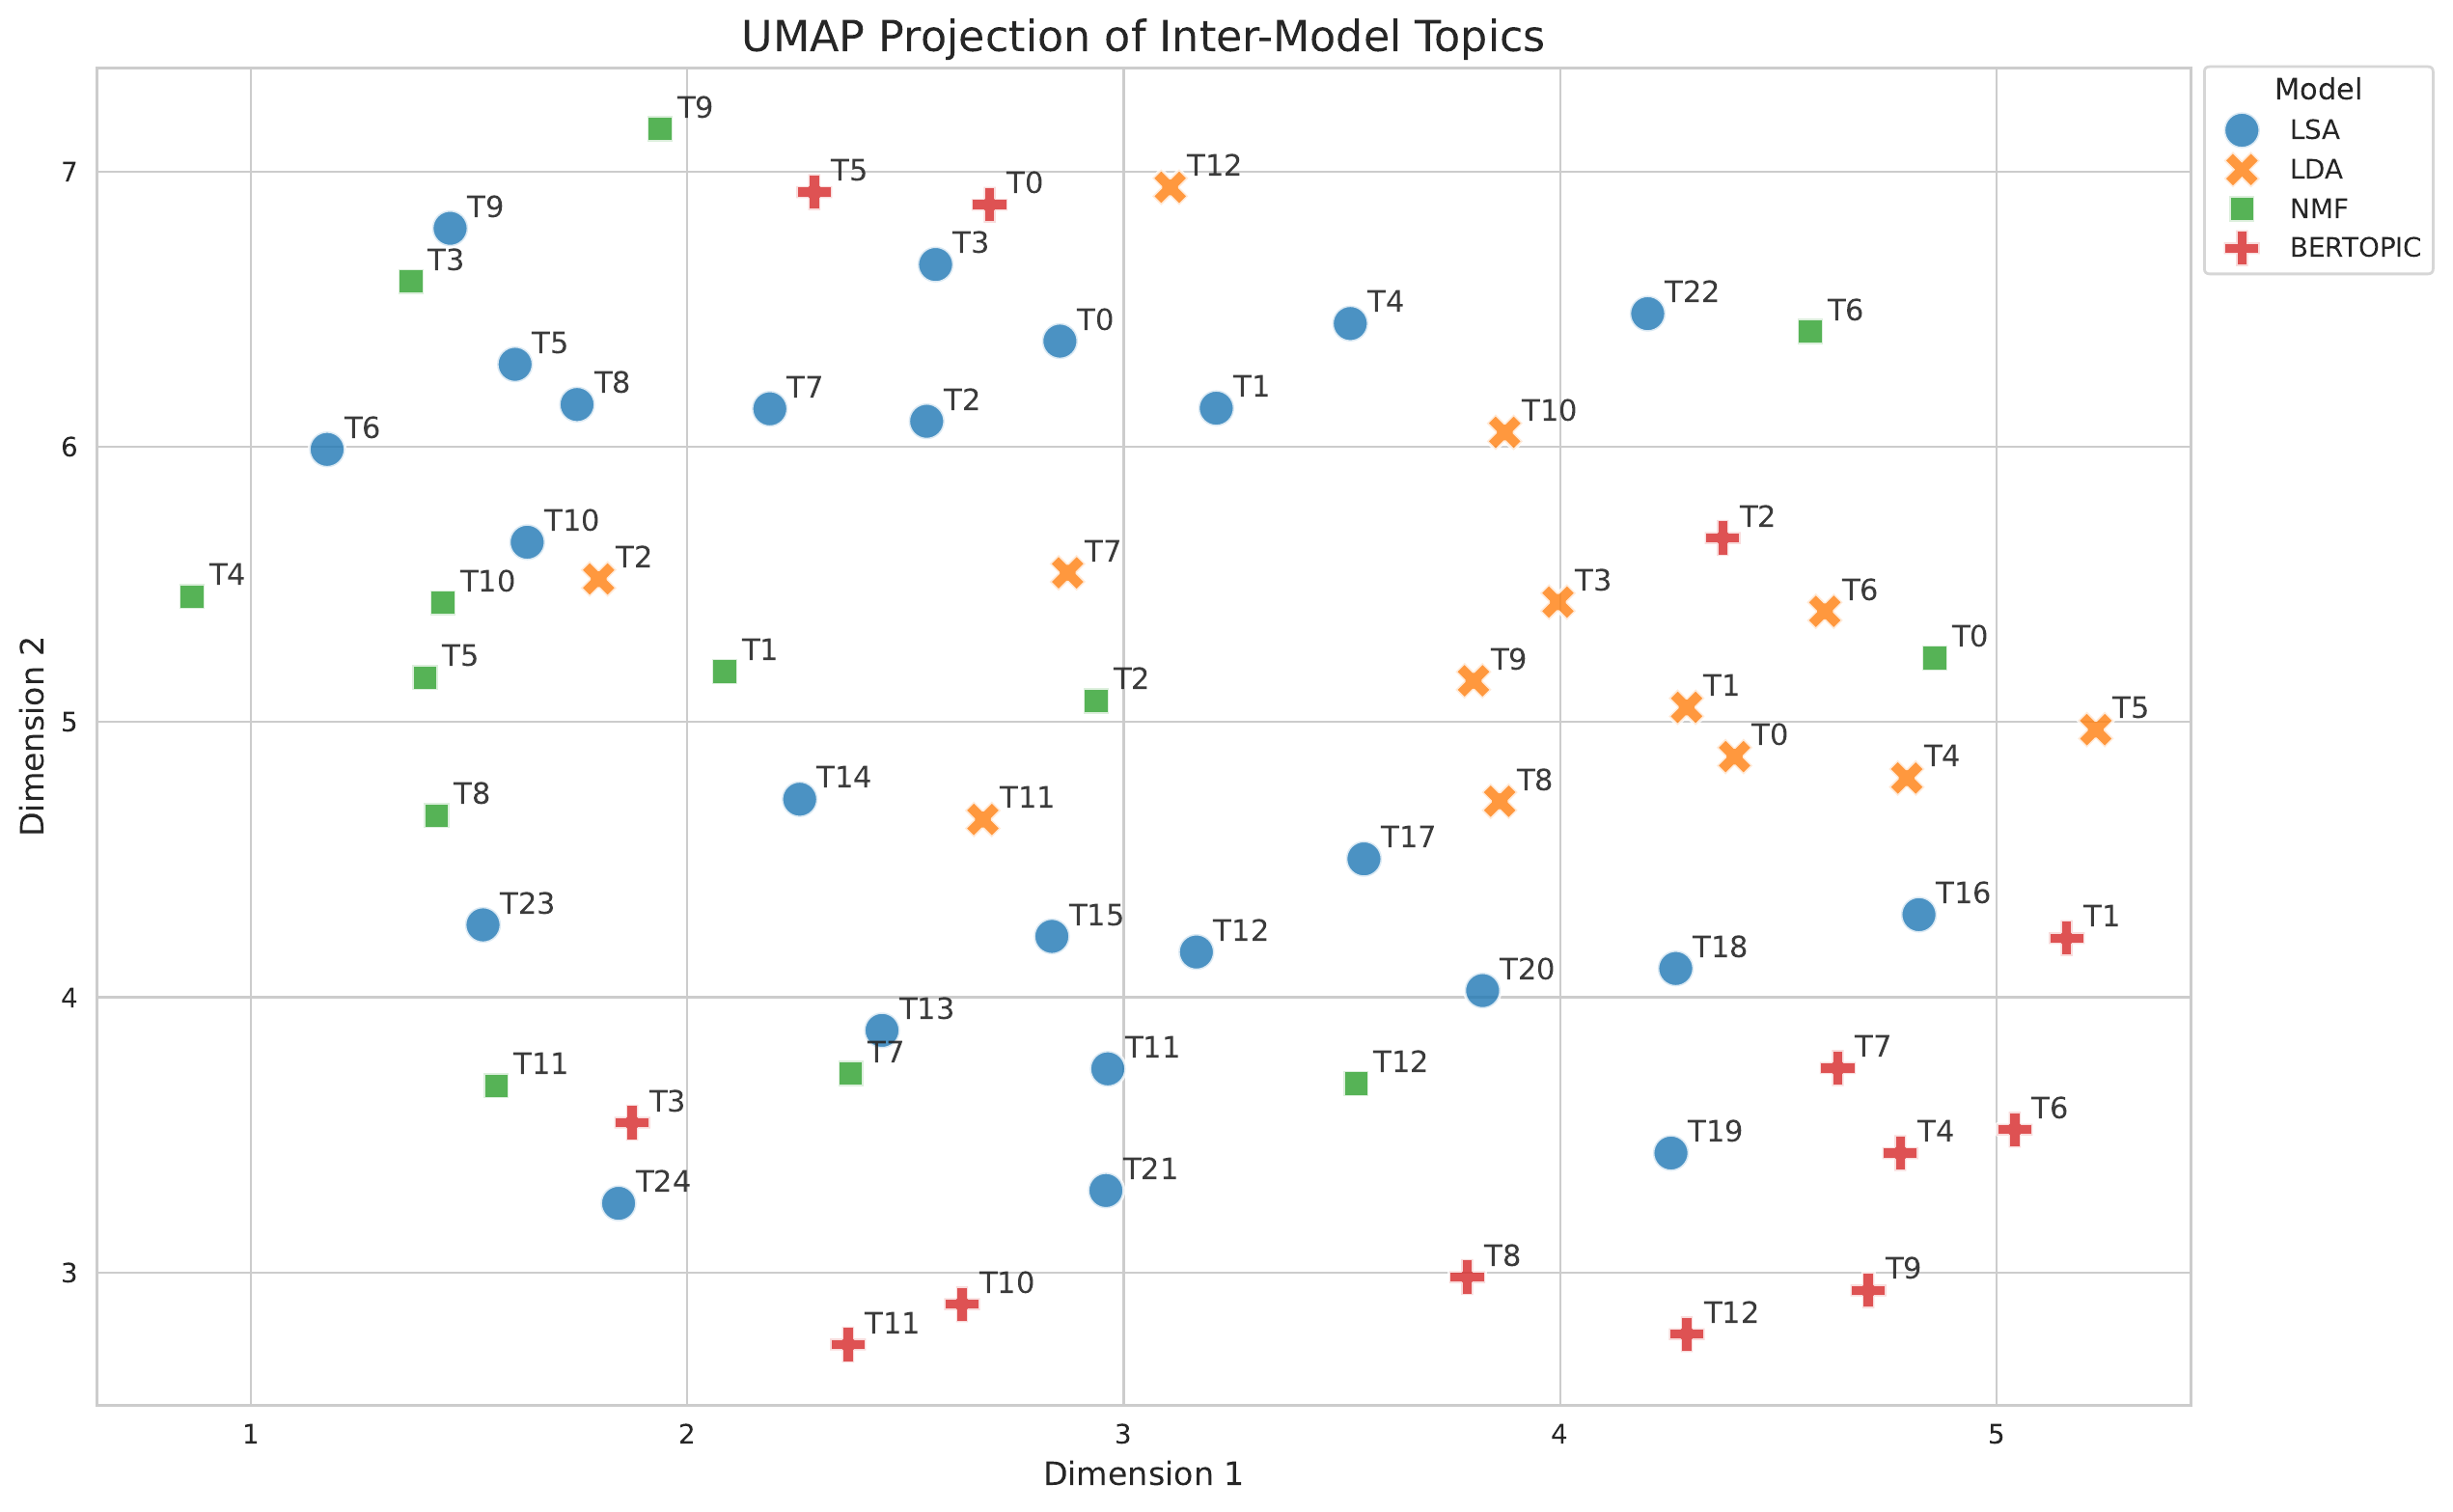

In [15]:
umap_view = os.path.join(figures_path, "umap_projection.pdf")
convert_pdf_to_png(umap_view, figures_path)
display(Image(filename='../output/figure/umap_projection.png', width='700px'))

### Common Topics

The identification of common topics was achieved through a similarity graph approach coupled with community detection via the Louvain algorithm. The undirected graph in the subsequent figure illustrates the detected communities, detailing the specific models and their corresponding topics within each cluster.

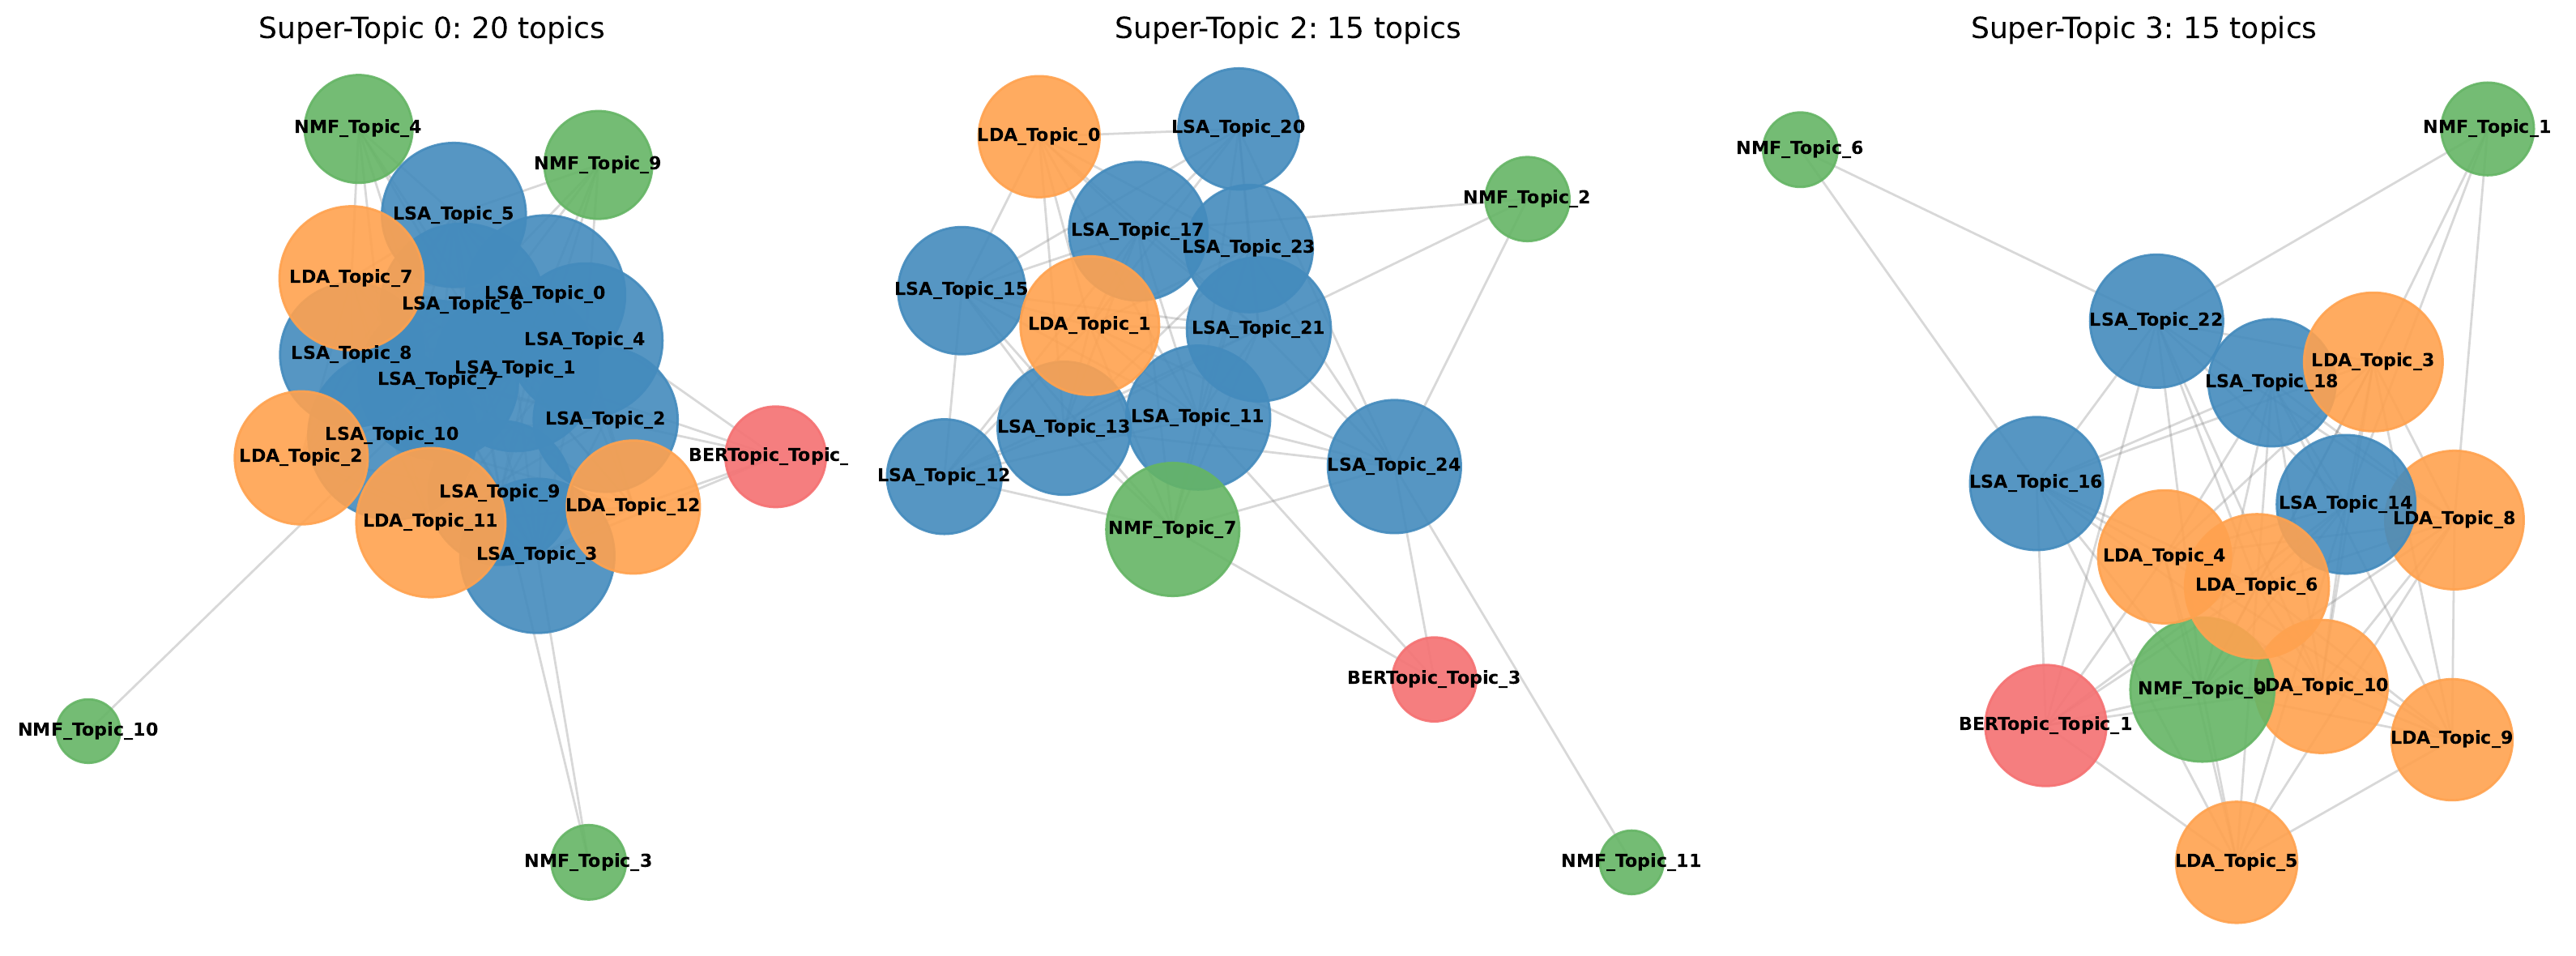

In [19]:
display(Image(filename='../output/figure/super_topics.png', width='700px'))

It can be observed that a single community may encompass multiple topics generated by the same model. To facilitate the analysis of these core themes, a single representative topic per model was selected within each community based on node degree. Since the degree of a node reflects its connectivity with others in the graph, the node with the highest degree effectively represents the central thematic focus of that model within the community. 

The following table presents the resulting Super-Topics along with their respective keywords from each model.

In [32]:
super_topics = pd.read_csv('../output/topic_modeling/super_topics.csv')
super_topics

,Super-Topic,LSA,LDA,NMF,BERTopic
0,0,"(1) excellent, good, didactic, explain, subject, teach, content, great, discipline, good, pass, test, know, class, miss","(7) subject, do, always, well, explain, class, material, great, interest, are, talk, take, time, teach, didactic","(4) well, explain, teach, subject, interact, educate, know, master, understand, con, lecture, reasoning, wonderful, quite, efficient","(0) excellent, always, great, good, didactic, excellent, good, doubts, subject, explains, content, about, super, objective"
1,2,"(21) semester, master, well, wonderful, to lack, about, form, to dedicate, difficult, to explain, to administer, to teach, commentary, subject, class","(1) class, leave, semester, work, teach, subject, some, topic, room, content, can, give, class, do, knowledge","(7) domain, subject, content, about, enough, matter, discipline, to teach, Portuguese, to contextualize, to teach, to deal with, form, clear, high","(3) domain, subject, content, quite, day, about, well, passes, knowledge, taught, area, subjects, new, contextualized, excellent"
2,3,"(14) class, teach, always, attentive, classroom, teaching methods, comment, general, student, to be absent, to help, method, test, to explain, willing","(8) subject, form, class, teach, material, because, can, do, student, manner, some, clear, discipline, only, evaluation","(0) class, for, test, content, to do, subject, work, evaluation, semester, little, to leave, form, to be able to, to achieve, to have","(1) content, test, room, evaluation, besides, tests, passed, teaching, lack, little, only, assignments, teaching methods, time, times"


### Exclusive Topics

The graph and community detection approach was also utilized in this context to identify exclusive topics captured by only a single model. These exclusive topics are identified because their cosine similarity with topics from other models falls below the defined threshold of 0.94, resulting in isolated nodes within the similarity graph. 

The following table presents the models and their identified exclusive topics.

In [33]:
exclusive_topics = pd.read_csv('../output/topic_modeling/exclusive_topics.csv')
exclusive_topics

,Model,Keywords
0,NMF,"(8) teach, bad, weak, possess, attention, objective, rushed, incredible, point, objective, congrats, approach, terrible, patience, approach"
1,NMF,"(12) miss, class, room, communication, experience, warn, punctual, inside, seen, of that, hardly, present, questions, personal, commitment"
2,BERTopic,"(2) schedule, times, reasons, some, time, many, too much, missed, fast, bus, night, work, many, punctual, are"
3,BERTopic,"(4) didactics, little, excellent, uncompromising, pretends, didactic, disorganized, terrible, points, extremely, knows, quite, unrealistic, right, explosive"
4,BERTopic,"(6) evaluation, evaluations, could, correction, clear, corrected, included, discursive, method, confusing, only, left, in, tests, forms"
5,BERTopic,"(8) nothing, joined, recorded, declare, arrives, nor, occurred, early, error, social, name, moment, evaluate, did, grade"
6,BERTopic,"(9) professional, ok, impeccable, qualified, fun, xxxxxxxxxxxx, regular, wonderful, wonderful, present, objective, name, sir, good, horrible"
7,BERTopic,"(10) comments, offensive, comment, read, comment, will be, positive, negative, unnecessary, never, other, so much, nothing, hour, ''"
8,BERTopic,"(11) improve, needs, leave, didactics, experience, interest, love, attract, gain, field, way, interesting, evolve, make an effort, content-focused"
9,BERTopic,"(12) sex, comments, sexual, ex, sexual, unnecessary, discussed, does, about, abuse, about, certain, approach, demanding, individual"


### Topic Frequency Distribution

To identify the predominant themes, the relative frequency distribution of the extracted topics was computed. The relevance of each theme was determined by counting the number of documents assigned to each topic. The relative frequency ($F_r$) per topic was obtained as the ratio between the count of comments belonging to a given topic ($N_t$) and the total number of comments in the corpus ($N_{total}$), as expressed by the following equation:
$$F_r = \left( \frac{N_t}{N_{total}} \right) \times 100$$
This metric enabled the identification of the three most recurrent topics for each of the analyzed models. The results of this distribution are presented below.

In [17]:
topics_freq = pd.read_csv('../output/topic_modeling/top3_topics_frequency_en.csv')

rank_labels = ['1st', '2nd', '3rd']

for model, group in topics_freq.groupby('Model', sort=False):
    print(f"\n{'='*60}")
    print(f" {model}")
    print(f"{'='*60}")
    for i, (_, row) in enumerate(group.iterrows()):
        print(f"  {rank_labels[i]}  |  Topic {row['Topic_ID']:>2}  |  {row['Freq_Pct']:>5}%  |  {row['Keywords']}")



 LSA
  1st  |  Topic  0  |   16.0%  |  good, excellent, didactics, great, professor, well, subject, class
  2nd  |  Topic 12  |    6.6%  |  absent, lecture, classroom, course, content, class, communication, about
  3rd  |  Topic 18  |    6.3%  |  exam, course, comment, pass, ability, clear, time, lecture

 LDA
  1st  |  Topic 11  |   16.3%  |  excellent, didactics, course, mastery, content, subject, good, always
  2nd  |  Topic 12  |   12.5%  |  good, great, didactics, professor, content, well, excellent, very
  3rd  |  Topic  6  |    8.7%  |  exam, class, pass, explain, content, assignment, well, semester

 NMF
  1st  |  Topic  0  |   23.6%  |  class, pass, exam, content, do, course, assignment, assessment
  2nd  |  Topic 12  |   11.0%  |  absent, lecture, classroom, communication, experience, notify, punctual, within
  3rd  |  Topic 11  |    9.5%  |  knowledge, general, subject, teach, comment, broad, know, so much

 BERTopic
  1st  |  Topic  0  |   41.9%  |  excellent, didactics, w

## Automatic generative topic labeling

This section focuses on the results of the automatic topic labeling performed using the Llama-3.1 LLM. For this stage, the topics generated by the BERTopic algorithm were selected. This choice is justified by BERTopic's demonstrated stability across Coherence and IRBO metrics, its synthesis capabilities observed during the common topics analysis, and its effectiveness in capturing crucial themes within the exclusive topics analysis. 

The following table presents the labels generated by the LLM alongside their respective topics.

In [34]:
llm_labels = pd.read_csv('../output/llm_labeling/bertopic_llm_labels_en_ver.csv')
llm_labels

,llm_label,keywords
0,Excellent Professor,"['excellent', 'always', 'great', 'well', 'good', 'didactics', 'great', 'good', 'doubts', 'subject', 'explains', 'content', 'about', 'super', 'objective']"
1,Inefficient and Disrespectful Professor With Students,"['content', 'test', 'room', 'evaluation', 'besides', 'tests', 'passed', 'teaching', 'lack', 'little', 'only', 'assignments', 'didactics', 'time', 'times']"
2,Infrastructure Problems and Excessive Classes,"['schedule', 'times', 'reasons', 'some', 'time', 'many', 'too much', 'missed', 'fast', 'bus', 'night', 'work', 'many', 'punctual', 'are']"
3,Subject Mastery is Well Taught,"['mastery', 'subject', 'content', 'quite', 'day', 'about', 'well', 'passes', 'knowledge', 'taught', 'area', 'subjects', 'new', 'contextualized', 'great']"
4,Extremely Disorganized Didactics,"['didactics', 'little', 'excellent', 'uncompromising', 'pretends', 'didactic', 'disorganized', 'terrible', 'points', 'extremely', 'knows', 'quite', 'unrealistic', 'right', 'explosive']"
5,Complicated Semester due to Lack of Communication and Strike,"['disciplines', 'some', 'good', 'difficulties', 'despite', 'strike', 'profitable', 'honestly', 'great', 'subjects', 'pass on', 'after', 'time', 'general', 'unfortunately']"
6,Inadequate Evaluation Method,"['evaluation', 'evaluations', 'could', 'correction', 'clear', 'corrected', 'included', 'discursive', 'method', 'con']"
7,Willing and Attentive Professor,"['always', 'attentive', 'willing', 'solicitous', 'humble', 'hardworking', 'congratulations', 'helpful', 'help', 'well', 'understood', 'engaged', 'disciplined', 'highly', 'arbitrary']"
8,Dissatisfaction with Absence of Information,"['nothing', 'joined', 'recorded', 'declare', 'arrives', 'nor', 'occurred', 'early', 'error', 'social', 'name', 'moment', 'evaluate', 'did', 'grade']"
9,Very Fun and Impeccable Class,"['professional', 'ok', 'impeccable', 'qualified', 'fun', 'xxxxxxxxxxxx', 'regular', 'wonderful', 'wonderful', 'present', 'objective', 'name', 'sir', 'good', 'horrible']"
